# 1. Overview

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')

In [ ]:
promotions = pd.read_csv("D:/vinuni_datathon2026/vinuni_datathon2026/raw_datasets/promotions.csv")
promotions.head()

,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,PROMO-0001,Spring Sale 2013,percentage,12.0,2013-03-18,2013-04-17,NaN,email,1,0
1,PROMO-0002,Mid-Year Sale 2013,percentage,18.0,2013-06-23,2013-07-22,NaN,online,0,0
2,PROMO-0003,Fall Launch 2013,percentage,10.0,2013-08-30,2013-10-02,NaN,email,0,0
3,PROMO-0004,Year-End Sale 2013,percentage,20.0,2013-11-18,2014-01-02,NaN,all_channels,0,50000
4,PROMO-0005,Urban Blowout 2013,fixed,50.0,2013-07-30,2013-09-02,Streetwear,online,0,150000


In [ ]:
promotions.shape

(50, 10)

In [ ]:
promotions.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   promo_id             50 non-null     str    
 1   promo_name           50 non-null     str    
 2   promo_type           50 non-null     str    
 3   discount_value       50 non-null     float64
 4   start_date           50 non-null     str    
 5   end_date             50 non-null     str    
 6   applicable_category  10 non-null     str    
 7   promo_channel        50 non-null     str    
 8   stackable_flag       50 non-null     int64  
 9   min_order_value      50 non-null     int64  
dtypes: float64(1), int64(2), str(7)
memory usage: 7.3 KB


In [ ]:
promotions.describe()

,discount_value,stackable_flag,min_order_value
count,50.000000,50.000000,50.000000
mean,18.500000,0.240000,46000.000000
std,11.241777,0.431419,66116.779802
min,10.000000,0.000000,0.000000
25%,12.000000,0.000000,0.000000
50%,16.500000,0.000000,0.000000
75%,20.000000,0.000000,100000.000000
max,50.000000,1.000000,200000.000000


In [ ]:
promotions.describe(include="object")

,promo_id,promo_name,promo_type,start_date,end_date,applicable_category,promo_channel
count,50,50,50,50,50,10,50
unique,50,50,2,50,50,2,5
top,PROMO-0001,Spring Sale 2013,percentage,2013-03-18,2013-04-17,Streetwear,all_channels
freq,1,1,45,1,1,5,19


## Tổng Quan Dữ Liệu: `promotions`

### 1. Mô Tả Bảng

Bảng **`promotions`** lưu trữ thông tin các chiến dịch khuyến mãi của doanh nghiệp theo từng năm. Mỗi bản ghi mô tả một chương trình giảm giá cụ thể, bao gồm loại giảm giá, thời hạn hiệu lực, kênh phân phối và điều kiện áp dụng.

---

### 2. Schema

| # | Cột | Kiểu | Ràng buộc | Mô tả |
|---|-----|------|-----------|-------|
| 0 | `promo_id` | `str` | PK · NOT NULL | Định danh duy nhất chiến dịch (VD: `PROMO-0001`) |
| 1 | `promo_name` | `str` | NOT NULL | Tên chiến dịch kèm năm (VD: `Spring Sale 2013`) |
| 2 | `promo_type` | `str` | NOT NULL | Loại giảm giá: `percentage` hoặc `fixed` |
| 3 | `discount_value` | `float64` | NOT NULL | Giá trị giảm (% hoặc số tiền cố định tuỳ `promo_type`) |
| 4 | `start_date` | `str` (date) | NOT NULL | Ngày bắt đầu chiến dịch (YYYY-MM-DD) |
| 5 | `end_date` | `str` (date) | NOT NULL | Ngày kết thúc chiến dịch (YYYY-MM-DD) |
| 6 | `applicable_category` | `str` | **NULLABLE** (40 null) | Danh mục áp dụng; null = áp dụng tất cả danh mục |
| 7 | `promo_channel` | `str` | NOT NULL | Kênh phân phối: `email`, `online`, `in_store`, `social_media`, `all_channels` |
| 8 | `stackable_flag` | `int64` | NOT NULL | `1` = cho phép dùng kèm KM khác · `0` = không cho phép |
| 9 | `min_order_value` | `int64` | NOT NULL | Giá trị đơn tối thiểu để áp dụng (0 = không yêu cầu) |

---

### 3. Thống Kê Tổng Quan

| Chỉ số | Giá trị |
|--------|---------|
| Tổng số chiến dịch | **50** |
| Tổng số cột | **10** |
| Khoảng thời gian | 2013 → 2022 (10 năm) |
| Loại khuyến mãi | `percentage` (đa số) · `fixed` (thiểu số) |
| Cột có NULL | `applicable_category` — 40/50 null (80%) → áp dụng toàn danh mục |
| `stackable_flag = 1` | Một phần nhỏ chiến dịch cho phép stack |
| `min_order_value = 0` | Nhiều chiến dịch không yêu cầu giá trị tối thiểu |


---

### 4. Lưu Ý Tiền Xử Lý

- Cột `start_date` và `end_date` đang ở kiểu `str` → cần chuyển sang `datetime` để tính **thời gian hiệu lực** của mỗi chiến dịch.
- `applicable_category` có **80% giá trị null** — cần điền nhãn `"all"` để xử lý thống nhất thay vì bỏ trống.
- `min_order_value = 0` nên được hiểu là **"không có ngưỡng tối thiểu"**, không phải thiếu dữ liệu.
- `stackable_flag` là biến nhị phân — có thể encode thành `bool` để rõ nghĩa hơn.


# 2. Check quality and preprocessing

In [ ]:
# 1. Unique PK
n_dup = promotions['promo_id'].duplicated().sum()
print(f"Duplicate promo_id: {n_dup} {'OK' if n_dup == 0 else 'Cần xử lý'}")

Duplicate promo_id: 0 OK


In [ ]:
# 2. Convert date columns sang datetime
for col in ['start_date', 'end_date']:
    promotions[col] = pd.to_datetime(promotions[col], format='%Y-%m-%d', errors='coerce')
    print(f"{col}: {promotions[col].dtype} | NaT: {promotions[col].isna().sum()}")

start_date: datetime64[us] | NaT: 0
end_date: datetime64[us] | NaT: 0


In [ ]:
# 3. Điền null applicable_category = 'all'
promotions['applicable_category'] = promotions['applicable_category'].fillna('all')
print(f"\napplicable_category null còn lại: {promotions['applicable_category'].isna().sum()}")
print(promotions['applicable_category'].value_counts())


applicable_category null còn lại: 0
applicable_category
all           40
Streetwear     5
Outdoor        5
Name: count, dtype: int64


In [ ]:
cat_cols = ['promo_type', 'applicable_category', 'promo_channel', 'stackable_flag']

for col in cat_cols:
    vc = promotions[col].value_counts(dropna=False)
    print(f"{'─'*45}")
    print(f"{col}  |  Distinct: {promotions[col].nunique()}")
    print(vc.to_string())
    print()


─────────────────────────────────────────────
promo_type  |  Distinct: 2
promo_type
percentage    45
fixed          5

─────────────────────────────────────────────
applicable_category  |  Distinct: 3
applicable_category
all           40
Streetwear     5
Outdoor        5

─────────────────────────────────────────────
promo_channel  |  Distinct: 5
promo_channel
all_channels    19
online          13
email            7
social_media     6
in_store         5

─────────────────────────────────────────────
stackable_flag  |  Distinct: 2
stackable_flag
0    38
1    12



In [ ]:
promotions.to_csv("D:/vinuni_datathon2026/vinuni_datathon2026/cleaned_datasets/promotions_cleaned.csv")

# 3. EDA

## 3.1 Phân phối dữ liệu

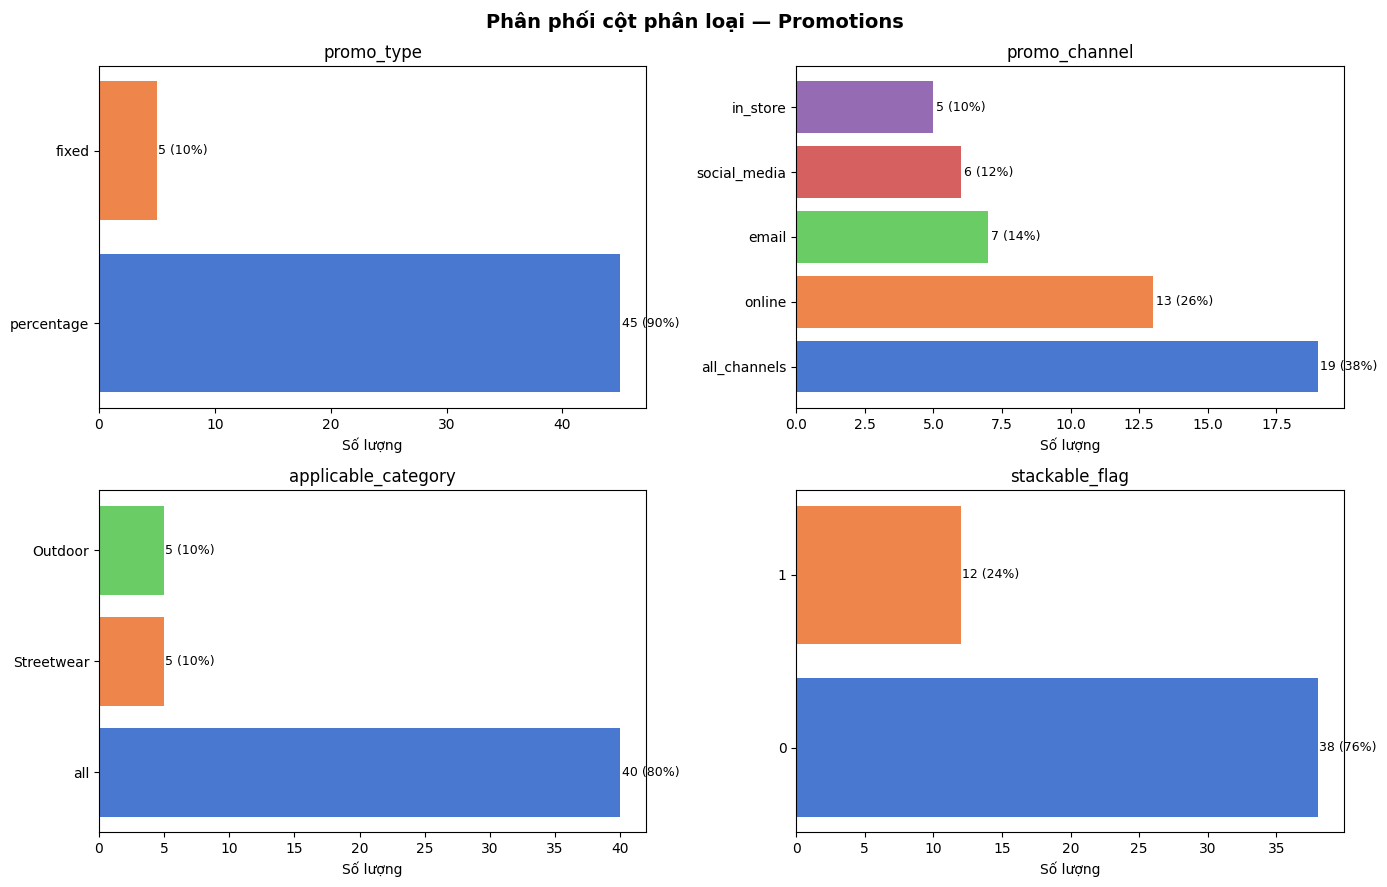

In [ ]:
# Phân phối categorical
cat_cols = ['promo_type', 'promo_channel', 'applicable_category', 'stackable_flag']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    vc = promotions[col].value_counts(dropna=False)
    ax.barh(vc.index.astype(str), vc.values, color=sns.color_palette("muted", len(vc)))
    ax.set_title(f"{col}")
    ax.set_xlabel("Số lượng")
    for i, v in enumerate(vc.values):
        ax.text(v + 0.1, i, f"{v} ({v/len(promotions)*100:.0f}%)", va='center', fontsize=9)

plt.suptitle("Phân phối cột phân loại — Promotions", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


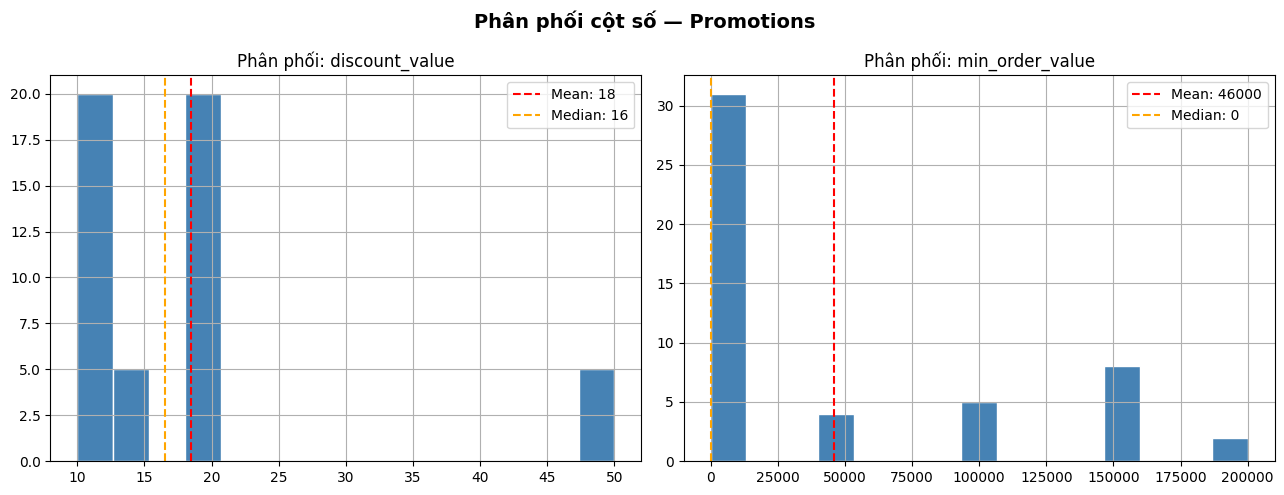

In [ ]:
# Phân phối cột số
num_cols = ['discount_value', 'min_order_value']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col in zip(axes, num_cols):
    promotions[col].hist(ax=ax, bins=15, color='steelblue', edgecolor='white')
    ax.axvline(promotions[col].mean(),   color='red',    linestyle='--', label=f"Mean: {promotions[col].mean():.0f}")
    ax.axvline(promotions[col].median(), color='orange', linestyle='--', label=f"Median: {promotions[col].median():.0f}")
    ax.set_title(f"Phân phối: {col}")
    ax.legend()

plt.suptitle("Phân phối cột số — Promotions", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


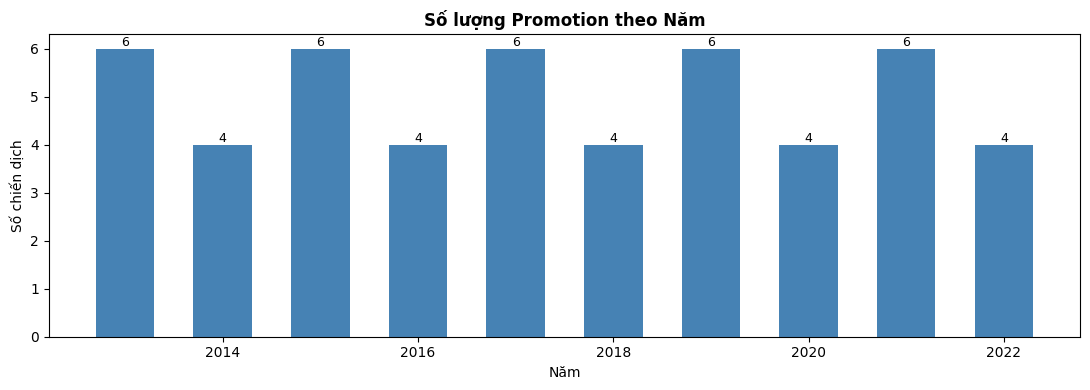

In [ ]:
#  Promotion theo năm
fig, ax = plt.subplots(figsize=(11, 4))

yearly = promotions.groupby(promotions['start_date'].dt.year).size()
ax.bar(yearly.index, yearly.values, color='steelblue', width=0.6)
ax.set_title("Số lượng Promotion theo Năm", fontweight='bold')
ax.set_xlabel("Năm")
ax.set_ylabel("Số chiến dịch")
for x, y in zip(yearly.index, yearly.values):
    ax.text(x, y + 0.05, str(y), ha='center', fontsize=9)

plt.tight_layout()
plt.show()


### Nhận Xét Tổng Quan

**Promo Type:** 90% chiến dịch dùng giảm giá theo **phần trăm (`percentage`)** — phù hợp để áp dụng đồng loạt mà không phụ thuộc vào giá trị sản phẩm. Chỉ 10% là `fixed` (giảm tiền mặt cố định), thường đi kèm danh mục cụ thể như Streetwear.

**Promo Channel:** `all_channels` chiếm 38% — doanh nghiệp ưu tiên **reach rộng** hơn là precision targeting. `online` (26%) xếp thứ 2, cho thấy digital là kênh chủ lực. Kênh offline `in_store` chỉ 10% — chiến lược tập trung vào e-commerce.

**Applicable Category:** 80% promotion áp dụng **toàn danh mục** — đây là chiến lược acquisition, không phải upsell. Chỉ `Streetwear` và `Outdoor` được nhắm mục tiêu riêng (mỗi loại 10%).

**Stackable Flag:** 76% không cho phép stack — doanh nghiệp **có ý thức bảo vệ margin**, tránh để khách hàng dùng nhiều ưu đãi cùng lúc.

**Discount Value:** Tập trung ở các mức cố định

**Min Order Value:** Median = **0** trong khi Mean = 46,000 → phân phối lệch phải mạnh. Phần lớn promotion **không yêu cầu ngưỡng đơn hàng** — ưu tiên tăng conversion hơn AOV.

**Số lượng theo năm:** Xen kẽ đều đặn giữa **4 và 6 chiến dịch/năm** (năm lẻ 6, năm chẵn 4). Đây là bằng chứng rõ nhất của **lịch promotion được lên kế hoạch cứng**, không phản ứng theo thị trường.


In [ ]:
promotions["discount_value"].unique()

array([12., 18., 10., 20., 50., 15.])

## 3.2 Phân Tích Quan Hệ Giữa Các Biến

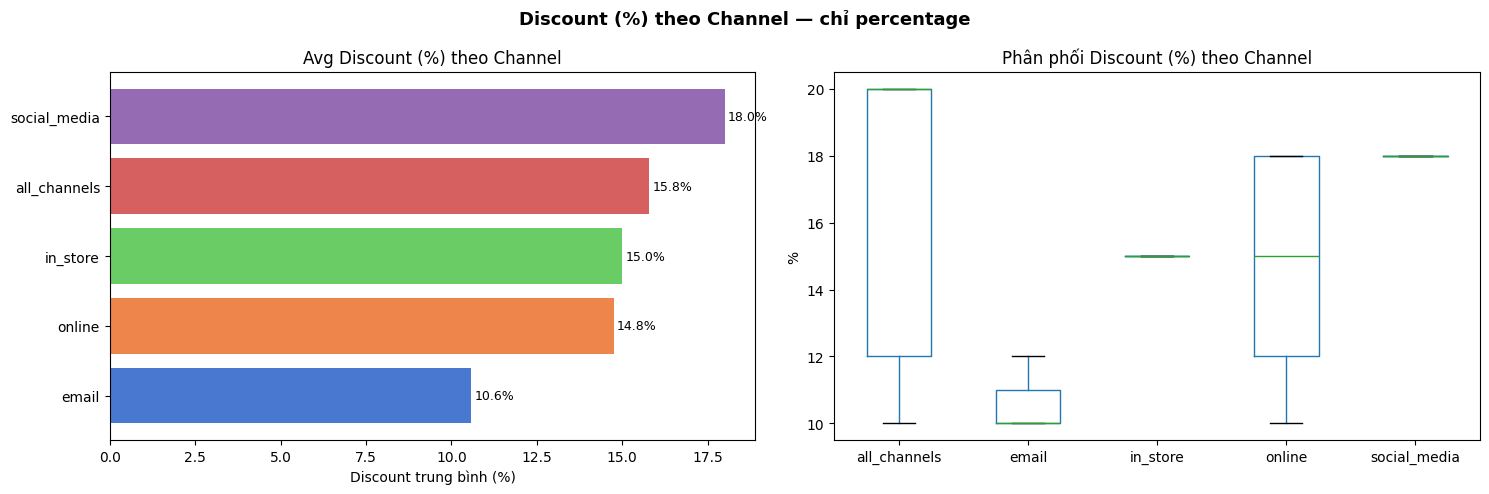

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

pct_df = promotions[promotions['promo_type'] == 'percentage']

# Avg discount (%) theo channel
ch_pct = pct_df.groupby('promo_channel')['discount_value'].mean().sort_values()
bars = axes[0].barh(ch_pct.index, ch_pct.values, color=sns.color_palette("muted", len(ch_pct)))
axes[0].set_title("Avg Discount (%) theo Channel")
axes[0].set_xlabel("Discount trung bình (%)")
for bar, v in zip(bars, ch_pct.values):
    axes[0].text(v + 0.1, bar.get_y() + bar.get_height()/2, f"{v:.1f}%", va='center', fontsize=9)

# Boxplot discount (%) theo channel
pct_df.boxplot(column='discount_value', by='promo_channel', ax=axes[1], grid=False)
axes[1].set_title("Phân phối Discount (%) theo Channel")
axes[1].set_xlabel("")
axes[1].set_ylabel("%")
plt.suptitle("")

plt.suptitle("Discount (%) theo Channel — chỉ percentage", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
promotions.loc[promotions["promo_type"] == "fixed"]

,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value,targeting
4,PROMO-0005,Urban Blowout 2013,fixed,50.0,2013-07-30,2013-09-02,Streetwear,online,0,150000,Targeted
14,PROMO-0015,Urban Blowout 2015,fixed,50.0,2015-07-30,2015-09-02,Streetwear,online,0,200000,Targeted
24,PROMO-0025,Urban Blowout 2017,fixed,50.0,2017-07-30,2017-09-02,Streetwear,online,0,150000,Targeted
34,PROMO-0035,Urban Blowout 2019,fixed,50.0,2019-07-30,2019-09-02,Streetwear,online,0,100000,Targeted
44,PROMO-0045,Urban Blowout 2021,fixed,50.0,2021-07-30,2021-09-02,Streetwear,online,0,200000,Targeted


`promo_type = "fixed` chỉ dùng cho `online` và `dicount_value` luôn là `50.0`

**Discount (%) theo Channel — Nhận Xét**

- **`social_media` có discount trung bình cao nhất (18%)** và **IQR rộng** → kênh này được dùng cho cả campaign nhỏ lẫn lớn, không cố định mức giảm.
- **`email` có discount thấp nhất (10.6%) và IQR rất hẹp (10–12%)** → kênh email chỉ dùng cho campaign nhẹ, nhắm đến khách hàng đã có sẵn — không cần "mồi" lớn.
- **`in_store` luôn ở mức cố định 15%** (median = 15, không có biến thiên) → discount offline được template hoá cứng, không linh hoạt.
- **`online` và `all_channels` có IQR rộng nhất** → hai kênh này phục vụ nhiều loại campaign khác nhau (từ Spring Sale 12% đến Year-End Sale 20%).

> **Insight:** `email` là kênh retention chi phí thấp; `social_media` là kênh acquisition với discount cao hơn để thu hút người mới.


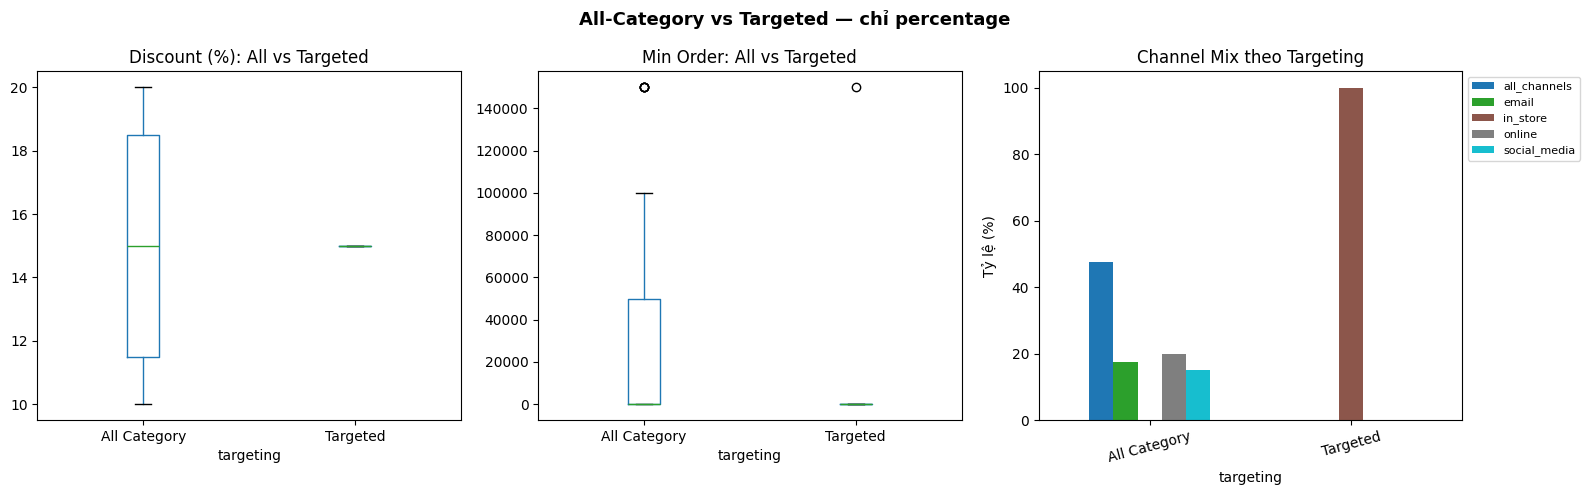

              discount_value  min_order_value
targeting                                    
All Category            15.0          33750.0
Targeted                15.0          30000.0


In [ ]:
promotions['targeting'] = promotions['applicable_category'].apply(
    lambda x: 'All Category' if x == 'all' else 'Targeted'
)

pct_df = promotions[promotions['promo_type'] == 'percentage']  # chỉ percentage

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pct_df.boxplot(column='discount_value', by='targeting', ax=axes[0], grid=False)
axes[0].set_title("Discount (%): All vs Targeted")
plt.suptitle("")

pct_df.boxplot(column='min_order_value', by='targeting', ax=axes[1], grid=False)
axes[1].set_title("Min Order: All vs Targeted")
plt.suptitle("")

cross = pd.crosstab(pct_df['targeting'], pct_df['promo_channel'], normalize='index') * 100
cross.plot(kind='bar', ax=axes[2], colormap='tab10', width=0.6)
axes[2].set_title("Channel Mix theo Targeting")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=15)
axes[2].set_ylabel("Tỷ lệ (%)")
axes[2].legend(bbox_to_anchor=(1, 1), fontsize=8)

plt.suptitle("All-Category vs Targeted — chỉ percentage", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(pct_df.groupby('targeting')[['discount_value', 'min_order_value']].mean().round(2))

**All-Category vs Targeted**

- **Discount ngang nhau (15%)** ở cả hai nhóm → khi loại bỏ `fixed`, doanh nghiệp **không ưu đãi thêm cho danh mục cụ thể** về mức giảm giá.
- **Min order gần như bằng nhau** (33,750 vs 30,000) và Targeted có IQR rất hẹp (gần 0) → campaign targeted `percentage` thường **không yêu cầu ngưỡng đơn hàng**, dễ tiếp cận hơn.
- **Channel mix là điểm khác biệt lớn nhất:** All Category trải đều trên nhiều kênh (`all_channels` 47%, `email`, `online`, `social_media`). Trong khi Targeted `percentage` **100% dùng `in_store`** → chiến dịch danh mục cụ thể (Outdoor) được đẩy hoàn toàn qua kênh offline.
> **Insight điều chỉnh:** Sự khác biệt giữa All vs Targeted **không nằm ở mức giảm**, mà ở **kênh phân phối**. `in_store` là kênh độc quyền cho targeted promotion — phù hợp với sản phẩm cần trải nghiệm trực tiếp như Outdoor.

# TỔNG HỢP

### 1. Tiền xử lí

| Bước | Hành động | Lý do |
|------|-----------|-------|
| **Kiểm tra PK** | Xác nhận `promo_id` unique 100% | Đảm bảo không có campaign trùng lặp |
| **Convert datetime** | `start_date`, `end_date`: `str` → `datetime64` | Cho phép tính duration, group theo năm/tháng |
| **Điền null** | `applicable_category`: NaN → `'all'` | 80% null = áp dụng toàn danh mục, không phải thiếu dữ liệu |


---

### 2. Tổng Hợp Insight

#### Cấu trúc Campaign
- **90% campaign dùng `percentage`**, chỉ 10% dùng `fixed` (50,000đ) — và toàn bộ `fixed` nhắm vào danh mục **Streetwear** qua kênh `online`.
- **Mức discount chuẩn hoá**: 10% · 12% · 15% · 18% · 20%→ lịch khuyến mãi được **template hoá cứng**, không linh hoạt theo thị trường.
- Số campaign xen kẽ **6 năm lẻ / 4 năm chẵn** — bằng chứng của kế hoạch promotion được lên lịch trước, không phản ứng thị trường.

#### Kênh phân phối
- `all_channels` chiếm 38% — ưu tiên **reach rộng** hơn precision targeting.
- `email` có discount thấp nhất (10.6%) và ít biến thiên → kênh **retention**, dùng để giữ khách hàng trung thành.
- `social_media` có discount cao nhất (18%) → kênh **acquisition**, cần mồi lớn hơn để thu hút người mới.
- **Targeted `percentage` campaign 100% dùng `in_store`** → danh mục Outdoor cần trải nghiệm trực tiếp trước khi mua.

#### Chiến lược All vs Targeted
- Khi chỉ xét `percentage`: discount **ngang nhau (15%)** ở cả All Category lẫn Targeted — không có ưu đãi thêm cho danh mục cụ thể.
- Điểm khác biệt thực sự nằm ở **kênh**: All Category trải đều nhiều kênh; Targeted chỉ dùng `in_store`.
- `fixed` campaign (Streetwear) có discount thực tế cao hơn và `min_order_value` lớn hơn → **bảo vệ margin** cho danh mục cao cấp.

#### Rủi ro & Điểm Yếu
- Lịch promotion quá dự đoán được → khách hàng có thể **"train"** để chỉ mua khi có sale.
- 76% campaign **non-stackable** cho thấy có ý thức kiểm soát chi phí, nhưng thiếu cơ chế loyalty.
- Không có cá nhân hoá theo phân khúc khách hàng — tất cả đang nhận cùng một mức giảm.
